In [1]:
import json
# Load filtered dataset
with open("./research_products_data/research_products_filtered.json", "r", encoding="utf-8") as f:
    filtered_data = json.load(f)

# Load citation_set
with open("./research_products_data/citation_set.json", "r", encoding="utf-8") as f:
    citation_set = json.load(f)

In [2]:
# numbr of entry for each one
filtered_len = len(filtered_data)
citation_len = len (citation_set)

print("Number of entries in filtered dataset:", filtered_len)
print("Number of entries in citation set:", citation_len)

Number of entries in filtered dataset: 258940
Number of entries in citation set: 7867254


In [3]:
!pip install networkx
import networkx as nx

id_to_data = {item["id"]: item for item in filtered_data}
G = nx.DiGraph()

# Funzione per aggiungere nodo con attributi
def add_node_with_type(node_id):
    if node_id in id_to_data:
        G.add_node(node_id, **id_to_data[node_id], external=False)
    else:
        G.add_node(node_id, external=True)

# Aggiungi nodi UNIPI
for node_id in id_to_data:
    add_node_with_type(node_id)

# Aggiungi archi e nodi esterni
for citation in citation_set:
    if len(citation) >= 3:
        source, target, relation = citation[0], citation[1], citation[2]
        add_node_with_type(source)
        add_node_with_type(target)
        if relation == "Cite":
            G.add_edge(source, target, type=relation)
        elif relation == "IsCitedBy":
            G.add_edge(target, source, type=relation)

In [4]:
# print number of edges and nodes of the graph
print("Number of nodes in the graph:", G.number_of_nodes())
print("Number of edges in the graph:", G.number_of_edges())


Number of nodes in the graph: 4743808
Number of edges in the graph: 7867254


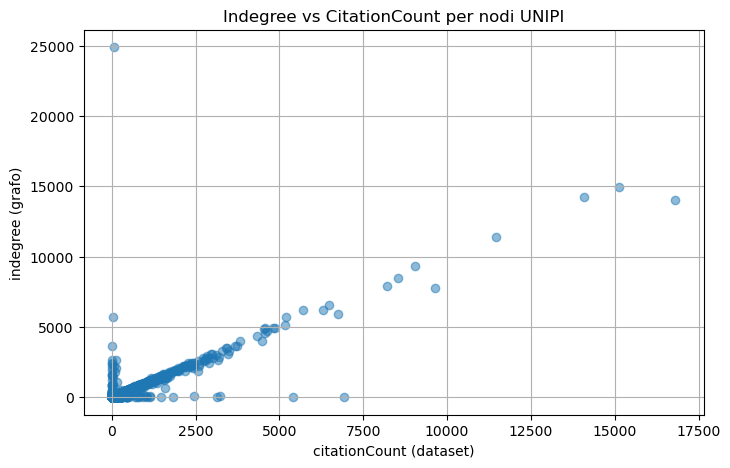

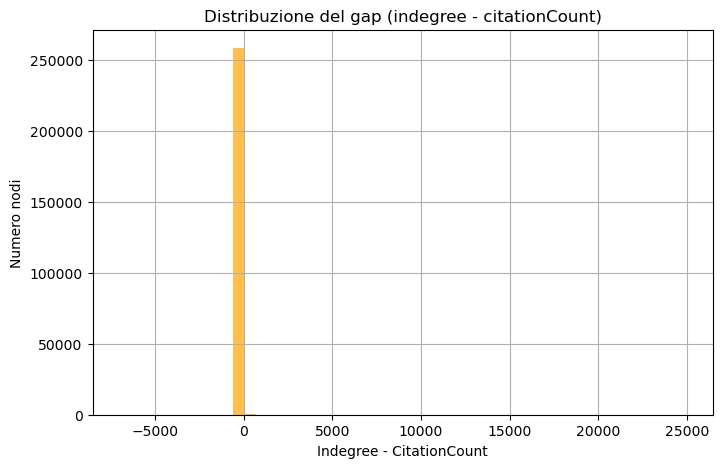

Errore medio assoluto tra indegree e citationCount: 1.78


In [5]:
!pip install matplotlib
!pip install numpy
import matplotlib.pyplot as plt
import numpy as np

unipi_nodes = [
    (node, data)
    for node, data in G.nodes(data=True)
    if (
        not data.get("external", True)
        and isinstance(data.get("indicators"), dict)
        and isinstance(data["indicators"].get("citationImpact"), dict)
    )
]

indegree_list = []
citation_count_list = []
gap_list = []

for node, data in unipi_nodes:
    indegree = G.in_degree(node)
    citation_count = data["indicators"]["citationImpact"].get("citationCount", 0)
    indegree_list.append(indegree)
    citation_count_list.append(citation_count)
    gap_list.append(indegree - citation_count)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(citation_count_list, indegree_list, alpha=0.5)
plt.xlabel("citationCount (dataset)")
plt.ylabel("indegree (grafo)")
plt.title("Indegree vs CitationCount per nodi UNIPI")
plt.grid(True)
plt.show()

# Gap plot
plt.figure(figsize=(8,5))
plt.hist(gap_list, bins=50, color='orange', alpha=0.7)
plt.xlabel("Indegree - CitationCount")
plt.ylabel("Numero nodi")
plt.title("Distribuzione del gap (indegree - citationCount)")
plt.grid(True)
plt.show()

# Errore medio
mean_error = np.mean(np.abs(np.array(gap_list)))
print(f"Errore medio assoluto tra indegree e citationCount: {mean_error:.2f}")

In [6]:
# ...existing code...
import networkx as nx

id_to_data = {item["id"]: item for item in filtered_data}
G = nx.DiGraph()

def add_node_with_type(node_id):
    if node_id in id_to_data:
        if node_id in G:
            G.nodes[node_id].update(id_to_data[node_id])
            G.nodes[node_id]["external"] = False
        else:
            G.add_node(node_id, **id_to_data[node_id], external=False)
    else:
        if node_id not in G:
            G.add_node(node_id, external=True)

# Nodi interni (UNIPI)
for node_id in id_to_data:
    add_node_with_type(node_id)

skipped_external_to_internal = 0
skipped_external_to_external = 0
added_edges = 0

for citation in citation_set:
    if len(citation) >= 3:
        src_raw, tgt_raw, relation = citation[0], citation[1], citation[2]
        add_node_with_type(src_raw)
        add_node_with_type(tgt_raw)

        # Orientamento (citing -> cited)
        if relation == "Cite":
            edge_source, edge_target = src_raw, tgt_raw
        elif relation == "IsCitedBy":
            edge_source, edge_target = tgt_raw, src_raw
        else:
            continue

        src_ext = G.nodes[edge_source].get("external", True)
        tgt_ext = G.nodes[edge_target].get("external", True)

        # Skip EXT -> UNIPI
        if src_ext and not tgt_ext:
            skipped_external_to_internal += 1
            continue
        # Skip EXT -> EXT
        if src_ext and tgt_ext:
            skipped_external_to_external += 1
            continue

        G.add_edge(edge_source, edge_target, type=relation)
        added_edges += 1

print(f"Archi aggiunti: {added_edges}")
print(f"Archi scartati (EXT -> UNIPI): {skipped_external_to_internal}")
print(f"Archi scartati (EXT -> EXT): {skipped_external_to_external}")
print(f"Nodi totali: {G.number_of_nodes()} | Archi totali: {G.number_of_edges()}")


Archi aggiunti: 4172493
Archi scartati (EXT -> UNIPI): 3687566
Archi scartati (EXT -> EXT): 7195
Nodi totali: 4743808 | Archi totali: 4172493


In [7]:
# Drop nodes with no links
isolated_nodes = list(nx.isolates(G))
G.remove_nodes_from(isolated_nodes)
print("Number of isolated nodes removed:", len(isolated_nodes))

Number of isolated nodes removed: 2414527


In [8]:
# Stampa la struttura del grafo
print("\nStruttura del grafo:")
print("Numero di nodi:", G.number_of_nodes())
print("Numero di archi:", G.number_of_edges())


Struttura del grafo:
Numero di nodi: 2329281
Numero di archi: 4172493


In [9]:
# ...existing code...
# Conteggi nodi
unipi_nodes = [n for n, d in G.nodes(data=True) if not d.get("external", True)]
external_nodes = [n for n, d in G.nodes(data=True) if d.get("external", True)]

print(f"Nodi UNIPI (internal): {len(unipi_nodes)}")
print(f"Nodi NON UNIPI (external): {len(external_nodes)}")
print(f"Totale nodi (check): {G.number_of_nodes()}")

# Conteggi archi per combinazione (source_type -> target_type)
def is_unipi(node_id):
    return not G.nodes[node_id].get("external", True)

edge_counts = {
    ("UNIPI","UNIPI"): 0,
    ("UNIPI","EXT"): 0,
    ("EXT","UNIPI"): 0,
    ("EXT","EXT"): 0
}

for u, v in G.edges():
    src_type = "UNIPI" if is_unipi(u) else "EXT"
    tgt_type = "UNIPI" if is_unipi(v) else "EXT"
    edge_counts[(src_type, tgt_type)] += 1

print("\nArchi per combinazione source -> target:")
print(f"UNIPI -> UNIPI: {edge_counts[('UNIPI','UNIPI')]}")
print(f"UNIPI -> EXT  : {edge_counts[('UNIPI','EXT')]}")
print(f"EXT   -> UNIPI: {edge_counts[('EXT','UNIPI')]}")
print(f"EXT   -> EXT  : {edge_counts[('EXT','EXT')]}")
print(f"Totale archi (check): {G.number_of_edges()}")

# Se vuoi anche percentuali:
total_edges = G.number_of_edges() or 1
print("\nPercentuali:")
for k, v in edge_counts.items():
    print(f"{k[0]} -> {k[1]}: {v} ({(v/total_edges)*100:.2f}%)")

Nodi UNIPI (internal): 122704
Nodi NON UNIPI (external): 2206577
Totale nodi (check): 2329281

Archi per combinazione source -> target:
UNIPI -> UNIPI: 364168
UNIPI -> EXT  : 3808325
EXT   -> UNIPI: 0
EXT   -> EXT  : 0
Totale archi (check): 4172493

Percentuali:
UNIPI -> UNIPI: 364168 (8.73%)
UNIPI -> EXT: 3808325 (91.27%)
EXT -> UNIPI: 0 (0.00%)
EXT -> EXT: 0 (0.00%)


In [10]:
# ...existing code...
# Salvataggio grafo con fallback robusti
import os, json, pickle
from datetime import datetime
import networkx as nx

out_dir = "./outputs_graph"
os.makedirs(out_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

gpickle_path   = os.path.join(out_dir, f"citation_graph_{timestamp}.gpickle")
edgelist_path  = os.path.join(out_dir, f"citation_graph_edges_{timestamp}.edgelist")
nodes_jsonl_path = os.path.join(out_dir, f"citation_graph_nodes_{timestamp}.jsonl")
graphml_path   = os.path.join(out_dir, f"citation_graph_{timestamp}.graphml")

def save_gpickle(G, path):
    # Prova API standard
    try:
        from networkx.readwrite import gpickle as _gp
        _gp.write_gpickle(G, path)
        print("Salvato gpickle (networkx.readwrite.gpickle):", path)
        return
    except Exception as e1:
        pass
    # Fallback puro pickle
    with open(path, "wb") as f:
        pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)
    print("Salvato gpickle (fallback pickle.dump):", path)

save_gpickle(G, gpickle_path)

# Edge list (se fallisce stampa warning)
try:
    nx.write_edgelist(G, edgelist_path, data=["type"])
    print("Salvato edge list:", edgelist_path)
except Exception as e:
    print("WARNING: edge list non salvata:", e)

# Nodi JSONL
with open(nodes_jsonl_path, "w", encoding="utf-8") as f:
    for n, attrs in G.nodes(data=True):
        rec = {"id": n, **attrs}
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")
print("Salvati nodi JSONL:", nodes_jsonl_path)

# GraphML (serializza attributi complessi in JSON string). Avvolto in try.
def serialize_value(v):
    if v is None:
        return ""  # oppure "null"
    if isinstance(v, (str, int, float, bool)):
        return v
    return json.dumps(v, ensure_ascii=False)

try:
    G_graphml = nx.DiGraph()
    for n, attrs in G.nodes(data=True):
        cleaned = {}
        for k, v in attrs.items():
            sv = serialize_value(v)
            # GraphML non accetta stringhe vuote per tipi numerici: qui va bene come stringa
            cleaned[k] = sv
        G_graphml.add_node(n, **cleaned)
    for u, v, attrs in G.edges(data=True):
        cleaned_e = {}
        for k, vv in attrs.items():
            sv = serialize_value(vv)
            cleaned_e[k] = sv
        G_graphml.add_edge(u, v, **cleaned_e)
    nx.write_graphml(G_graphml, graphml_path)
    print("Salvato GraphML:", graphml_path)
except Exception as e:
    print("WARNING: GraphML non salvato:", e)

print(f"Riepilogo -> Nodi: {G.number_of_nodes()} | Archi: {G.number_of_edges()}")

Salvato gpickle (fallback pickle.dump): ./outputs_graph/citation_graph_20250831_103443.gpickle
Salvato edge list: ./outputs_graph/citation_graph_edges_20250831_103443.edgelist
Salvati nodi JSONL: ./outputs_graph/citation_graph_nodes_20250831_103443.jsonl
Salvato GraphML: ./outputs_graph/citation_graph_20250831_103443.graphml
Riepilogo -> Nodi: 2329281 | Archi: 4172493
